<h1> Final Project Checkpoint

<h3> Data Cleaning for Legal Case Dataset

In [ ]:
import kagglehub

path = kagglehub.dataset_download("kageneko/legal-case-document-summarization")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/legal-case-document-summarization


In [ ]:
import os
import re
import pandas as pd
from nltk.tokenize import sent_tokenize
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
judgment_dir = "/kaggle/input/legal-case-document-summarization/dataset/IN-Ext/judgement"
summary_dir = "/kaggle/input/legal-case-document-summarization/dataset/IN-Ext/summary"

filenames = sorted(os.listdir(judgment_dir))

CLAUSE_KEYWORDS = [
    "WHEREAS", "THEREFORE", "ORDERED", "IN THE MATTER OF", "DECREE", "JUDGMENT", "FINDINGS",
    "FACTUAL BACKGROUND", "CONCLUSIONS OF LAW", "IT IS FURTHER ORDERED"
]

In [ ]:
import os
import re
import pandas as pd
from nltk.tokenize import sent_tokenize
import nltk
nltk.download('punkt')

judgment_dir = "/kaggle/input/legal-case-document-summarization/dataset/IN-Ext/judgement"
summary_dirs = [
    "/kaggle/input/legal-case-document-summarization/dataset/IN-Ext/summary/full/A1",
    "/kaggle/input/legal-case-document-summarization/dataset/IN-Ext/summary/full/A2"
]

CLAUSE_KEYWORDS = [
    "WHEREAS", "THEREFORE", "ORDERED", "IN THE MATTER OF", "DECREE",
    "JUDGMENT", "FINDINGS", "FACTUAL BACKGROUND", "CONCLUSIONS OF LAW", "IT IS FURTHER ORDERED"
]

def extract_clauses(text):
    lines = text.split('\n')
    clauses = []
    current_clause = ""
    for line in lines:
        line = line.strip()
        if any(k in line.upper() for k in CLAUSE_KEYWORDS):
            if current_clause:
                clauses.append(current_clause.strip())
            current_clause = line
        else:
            current_clause += " " + line
    if current_clause:
        clauses.append(current_clause.strip())
    return clauses

records = []
for fname in sorted(os.listdir(judgment_dir)):
    case_id = fname.replace(".txt", "")

    with open(os.path.join(judgment_dir, fname), 'r', encoding='utf-8', errors='ignore') as f:
        full_text = f.read()

    summary_text = ""
    found = False
    for dir_path in summary_dirs:
        summary_path = os.path.join(dir_path, fname)
        if os.path.exists(summary_path):
            with open(summary_path, 'r', encoding='utf-8', errors='ignore') as f:
                summary_text = f.read()
                found = True
                break

    if not found:
        continue  

    cleaned_text = re.sub(r'\s+', ' ', full_text).strip()
    cleaned_summary = re.sub(r'\s+', ' ', summary_text).strip()
    clauses = extract_clauses(cleaned_text)
    sentences = sent_tokenize(cleaned_text)

    records.append({
        "case_id": case_id,
        "full_text": cleaned_text,
        "summary": cleaned_summary,
        "clauses": clauses,
        "sentences": sentences
    })

df = pd.DataFrame(records)

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


<h3> Cleaned Dataset for Legal Cases

In [ ]:
df.head(25)

,case_id,full_text,summary,clauses,sentences
0,1953_L_1,one lakshminarayana iyer a hindu brahmin who o...,"FACTS lakshminarayana iyer, a hindu brahmin in...",[one lakshminarayana iyer a hindu brahmin who ...,[one lakshminarayana iyer a hindu brahmin who ...
1,1953_S_23,this is an appeal on a certificate article 133...,FACTS one dwarka nath was the owner of conside...,[this is an appeal on a certificate article 13...,[this is an appeal on a certificate article 13...
2,1954_M_25,this appeal with special leave is directed aga...,FACTS this appeal with special leave is direct...,[this appeal with special leave is directed ag...,[this appeal with special leave is directed ag...
3,1963_S_59,the respondent No. i was tried before the cour...,FACTS in 1929 the andhra engineering co.(aeco)...,[the respondent No. i was tried before the cou...,"[the respondent No., i was tried before the co..."
4,1971_S_1,this appeal is by special leave against the ju...,FACTS this appeal is by special leave against ...,[this appeal is by special leave against the j...,[this appeal is by special leave against the j...
5,1973_S_68,this appeal is by special leave against the ju...,FACTS it was the appellant's case that he had ...,[this appeal is by special leave against the j...,[this appeal is by special leave against the j...
6,1976_T_9,three civil appeals stemming from three revisi...,"FACTS three civil appeals, stemming from three...",[three civil appeals stemming from three revis...,[three civil appeals stemming from three revis...
7,1977_P_19,this appeal by special leave which is directed...,FACTS the respondent is a woman worker employe...,[this appeal by special leave which is directe...,[this appeal by special leave which is directe...
8,1978_M_13,the main question raised in this appeal by spe...,FACTS by hajur order the respondent was grante...,[the main question raised in this appeal by sp...,[the main question raised in this appeal by sp...
9,1980_W_3,this appeal by special leave has been preferre...,"FACTS tata consultant engineers,was a partners...",[this appeal by special leave has been preferr...,[this appeal by special leave has been preferr...


In [ ]:
df['num_clauses'] = df['clauses'].apply(len)

In [ ]:
def label_clause(clause):
    clause_upper = clause.upper()
    if any(keyword in clause_upper for keyword in ["FACT", "BACKGROUND", "INCIDENT"]):
        return "FACT"
    elif any(keyword in clause_upper for keyword in ["JUDGMENT", "DECIDED", "HELD", "OPINION"]):
        return "JUDGMENT"
    elif any(keyword in clause_upper for keyword in ["ORDERED", "DIRECTED", "ISSUED", "THEREFORE"]):
        return "ORDER"
    else:
        return "OTHER"

df['clause_labels'] = df['clauses'].apply(lambda clause_list: [label_clause(c) for c in clause_list])


In [ ]:
df.to_json("/kaggle/working/data/legal/processed/cleaned_legal_cases_with_labels.json", 
           orient="records", lines=True)

print("Saved as JSON instead of CSV!")

Saved as JSON instead of CSV!


In [ ]:
df_legal = pd.read_json("/kaggle/working/data/legal/processed/cleaned_legal_cases_with_labels.json", 
                  orient="records", lines=True)

In [ ]:
df_legal.head(25)

,case_id,full_text,summary,clauses,sentences,num_clauses,clause_labels
0,1953_L_1,one lakshminarayana iyer a hindu brahmin who o...,"FACTS lakshminarayana iyer, a hindu brahmin in...","""\""[\\\""one lakshminarayana iyer a hindu brahm...","""\""[\\\""one lakshminarayana iyer a hindu brahm...",1,"""\""[\\\""FACT\\\""]\"""""
1,1953_S_23,this is an appeal on a certificate article 133...,FACTS one dwarka nath was the owner of conside...,"""\""[\\\""this is an appeal on a certificate art...","""\""[\\\""this is an appeal on a certificate art...",1,"""\""[\\\""FACT\\\""]\"""""
2,1954_M_25,this appeal with special leave is directed aga...,FACTS this appeal with special leave is direct...,"""\""[\\\""this appeal with special leave is dire...","""\""[\\\""this appeal with special leave is dire...",1,"""\""[\\\""FACT\\\""]\"""""
3,1963_S_59,the respondent No. i was tried before the cour...,FACTS in 1929 the andhra engineering co.(aeco)...,"""\""[\\\""the respondent No. i was tried before ...","""\""[\\\""the respondent No.\\\"", \\\""i was trie...",1,"""\""[\\\""FACT\\\""]\"""""
4,1971_S_1,this appeal is by special leave against the ju...,FACTS this appeal is by special leave against ...,"""\""[\\\""this appeal is by special leave agains...","""\""[\\\""this appeal is by special leave agains...",1,"""\""[\\\""FACT\\\""]\"""""
5,1973_S_68,this appeal is by special leave against the ju...,FACTS it was the appellant's case that he had ...,"""\""[\\\""this appeal is by special leave agains...","""\""[\\\""this appeal is by special leave agains...",1,"""\""[\\\""FACT\\\""]\"""""
6,1976_T_9,three civil appeals stemming from three revisi...,"FACTS three civil appeals, stemming from three...","""\""[\\\""three civil appeals stemming from thre...","""\""[\\\""three civil appeals stemming from thre...",1,"""\""[\\\""FACT\\\""]\"""""
7,1977_P_19,this appeal by special leave which is directed...,FACTS the respondent is a woman worker employe...,"""\""[\\\""this appeal by special leave which is ...","""\""[\\\""this appeal by special leave which is ...",1,"""\""[\\\""FACT\\\""]\"""""
8,1978_M_13,the main question raised in this appeal by spe...,FACTS by hajur order the respondent was grante...,"""\""[\\\""the main question raised in this appea...","""\""[\\\""the main question raised in this appea...",1,"""\""[\\\""FACT\\\""]\"""""
9,1980_W_3,this appeal by special leave has been preferre...,"FACTS tata consultant engineers,was a partners...","""\""[\\\""this appeal by special leave has been ...","""\""[\\\""this appeal by special leave has been ...",1,"""\""[\\\""FACT\\\""]\"""""


In [ ]:
!pip install transformers
!pip install summa
!pip install sentencepiece


<h3>Abstractive Summarizer - An Example using Bart Large

In [ ]:
from transformers import pipeline
from tqdm import tqdm
import json

abstractive_summarizer = pipeline("summarization", model="facebook/bart-large-cnn", device=0)

def summarize_case(text, max_chunk_chars=1024):
    chunks = []
    while len(text) > max_chunk_chars:
        split_at = text[:max_chunk_chars].rfind('.')
        if split_at == -1:
            split_at = max_chunk_chars
        chunks.append(text[:split_at + 1])
        text = text[split_at + 1:]
    chunks.append(text)

    summaries = []
    for chunk in chunks:
        try:
            summary = abstractive_summarizer(chunk, max_length=130, min_length=30, do_sample=False)[0]['summary_text']
            summaries.append(summary)
        except Exception as e:
            summaries.append("[FAILED SUMMARY]")
    return " ".join(summaries)

summaries = []
for i, row in tqdm(df_legal.iterrows(), total=len(df_legal)):
    full_text = row['full_text'] if 'full_text' in row else " ".join(row.get('sentences', []))
    summaries.append(summarize_case(full_text))

df_legal["generated_summary"] = summaries

df_legal.to_json("/kaggle/working/data/legal/processed/final_with_summaries.json", orient='records', lines=False)
print("Summarization done and saved!")


In [ ]:
!pip install evaluate

In [ ]:
!pip install rouge_score

In [ ]:
print(df_legal.columns)

Index(['case_id', 'full_text', 'summary', 'clauses', 'sentences',
       'num_clauses', 'clause_labels', 'generated_summary'],
      dtype='object')


Evaluation of Pretrained BART Model

In [ ]:
import evaluate
import pandas as pd

rouge = evaluate.load("rouge")

df_eval = df_legal.dropna(subset=["generated_summary", "summary"])

predictions = df_eval["generated_summary"].astype(str).tolist()
references = df_eval["summary"].astype(str).tolist()

results = rouge.compute(predictions=predictions, references=references)

for metric, score in results.items():
    print(f"{metric}: {score:.4f}")


rouge1: 0.6917
rouge2: 0.4543
rougeL: 0.3549
rougeLsum: 0.3549


In [ ]:
from evaluate import load

bleu = load("bleu")

bleu_inputs = {
    "predictions": predictions,
    "references": [[ref] for ref in references] 
}

bleu_result = bleu.compute(**bleu_inputs)

print(f"\nBLEU Score: {bleu_result['bleu']:.4f}")



BLEU Score: 0.3371


In [ ]:
sample_case = df_legal.iloc[0]

print("FULL CASE TEXT \n")
print(sample_case['full_text'])

print("\nGENERATED SUMMARY:\n")
print(sample_case['generated_summary'])

if 'reference_summary' in df_legal.columns:
    print("\nREFERENCE SUMMARY:\n")
    print(sample_case['reference_summary'])


FULL CASE TEXT 

one lakshminarayana iyer a hindu brahmin who owned considerable properties in the tirunelveli district died on 13th december 1924 leaving him surviving a widow ranganayaki and a married daughter ramalakshmi. ramalakshmi had married the plaintiff and had a number of children from him. they were all alive in december 1924 when lakshminarayana died. before his death he executed a will on 16th november 1924 the construction of which is in controversy in this appeal. by this will he gave the following directions after my lifetime you the aforesaid ranganayaki amminal my wife shall till your lifetime enjoy the aforesaid entire properties the outstandings due to me the debts payable by me and the chit amounts payable by me. after your lifetime ramalakshmi ammal our daughter and wife of rama ayyar avergal of melagaram village and her heirs shall enjoy them with absolute rights and powers of alienation such as gift exchange and sale from son to grandson and so on for generation

### Dataset Extraction of CNN Dataset


In [ ]:
import zipfile
import os

zip_path = "/content/cnn_dailymail.zip"
extract_path = "/content/unzipped_folder"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


### Library Installation

In [ ]:
!pip install --upgrade transformers

In [ ]:
!pip install transformers datasets torch accelerate rouge-score

### Model and Dataset Initialization
This cell loads the pretrained model and tokenization. It also reads and samples subsets from the training, validation, of the dataset.


In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import pandas as pd
from datasets import Dataset

model_name = "t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
train_df = pd.read_csv("/content/unzipped_folder/cnn_dailymail/train.csv").sample(2000, random_state=42)
val_df = pd.read_csv("/content/unzipped_folder/cnn_dailymail/validation.csv").sample(500, random_state=42)
test_df = pd.read_csv("/content/unzipped_folder/cnn_dailymail/test.csv").sample(200, random_state=42)
def preprocess_function(examples):
    inputs = tokenizer(examples["article"], truncation=True, padding="max_length", max_length=384)
    targets = tokenizer(examples["highlights"], truncation=True, padding="max_length", max_length=128)
    inputs["labels"] = targets["input_ids"]
    return inputs

train_dataset = Dataset.from_pandas(train_df).map(preprocess_function, batched=True, num_proc=4)
val_dataset = Dataset.from_pandas(val_df).map(preprocess_function, batched=True, num_proc=4)
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    save_strategy="epoch",
    evaluation_strategy="epoch",
    fp16=True,
    logging_steps=500,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)
trainer.train()

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

Map (num_proc=4):   0%|          | 0/2000 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/500 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Epoch,Training Loss,Validation Loss
1,No log,1.246208
2,1.800300,1.224536
3,1.800300,1.223466


TrainOutput(global_step=750, training_loss=1.6312785237630207, metrics={'train_runtime': 80.5237, 'train_samples_per_second': 74.512, 'train_steps_per_second': 9.314, 'total_flos': 609038106624000.0, 'train_loss': 1.6312785237630207, 'epoch': 3.0})

### Summary Generation
Defining a function to evaluate the model on a single, randomly selected test sample. It tokenizes the input, generates a summary using the trained model, and prints the result.


In [ ]:
import torch

def evaluate_model():
    sample = test_df.sample(1).iloc[0]
    input_text = sample["article"]
    reference_summary = sample["highlights"]

    inputs = tokenizer(input_text, return_tensors="pt", max_length=384, truncation=True)
    inputs = {k: v.to("cuda") for k, v in inputs.items()}

    summary_ids = model.generate(**inputs, max_length=100, min_length=30, num_beams=2)
    generated_summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    print("\nOriginal Text:\n", input_text)
    print("\nReference Summary:\n", reference_summary)
    print("\nGenerated Summary:\n", generated_summary)

evaluate_model()


Original Text:
 (CNN)Novak Djokovic extended his current winning streak to 17 matches after beating Thomas Berdych 7-5, 4-6, 6-3 in the rain-interrupted final of the Monte Carlo Masters. But the Serbian world number one didn't have it all his away under uncharacteristically slate gray skies on the Mediterranean coast. Tight . Djokovic edged a tight first set before losing the second after the Czech sixth seed took advantage of the short rain delay and came back strongly. But Djokovic broke twice early in the third set to surge to a 4-0 lead. And although Berdych gamely fought back Djokovic served out for the title. "It was a tough match, a particular match," said Djokovic after winning his 52nd career title, and his second Monte Carlo Masters championship. "Tomas played a great match and deserves this trophy as much as I do," he added. "It was a good final, but bad luck today." Despite running Djokovic close it was Berdych's third loss in a final this year. "What can I say? Novak had 

In [ ]:
pip install evaluate bert-score


### Model Evaluation Metrics
This section evaluates the summarization model using multiple metrics:
- **ROUGE**: Measures n-gram overlap between generated summaries and reference texts.
- **BERTScore**: Uses contextual embeddings to evaluate semantic similarity.
A bar chart is also generated to visualize the ROUGE scores for quick interpretation.


ROUGE Scores:
rouge1: 0.4012
rouge2: 0.1727
rougeL: 0.2743
rougeLsum: 0.3733
calculating scores...
computing bert embedding.


  0%|          | 0/4 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/2 [00:00<?, ?it/s]

done in 0.56 seconds, 177.94 sentences/sec

BERTScore F1: 0.6359


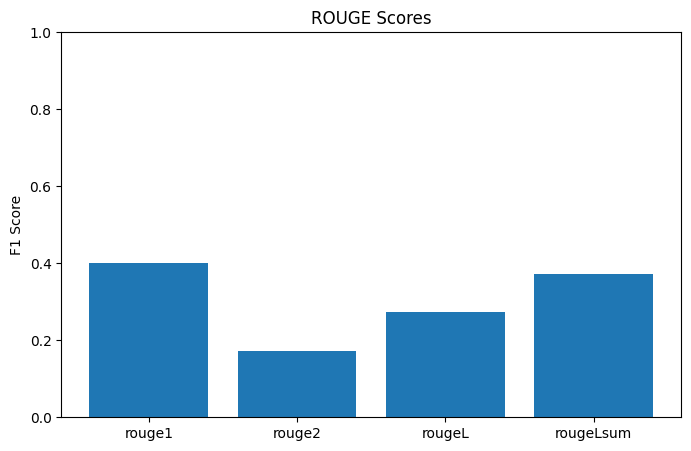

In [ ]:

rouge = evaluate.load("rouge")
rouge_result = rouge.compute(predictions=predictions, references=references)
print("ROUGE Scores:")
for key in rouge_result:
    print(f"{key}: {rouge_result[key]:.4f}")
P, R, F1 = bert_score(predictions, references, lang="en", model_type="bert-base-uncased", verbose=True)
print(f"\nBERTScore F1: {F1.mean().item():.4f}")
labels = list(rouge_result.keys())
scores = [rouge_result[score] for score in labels]

plt.figure(figsize=(8, 5))
plt.bar(labels, scores)
plt.title("ROUGE Scores")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.show()

### Saving the Trained Model


In [ ]:
torch.save(model.state_dict(), "textSummaryBaseModelt5.pt")